In [ ]:
import os
import sys
sys.path.append(os.path.abspath("/home/users/zhiyi/PROJECTS_ANALYSIS"))
os.environ['PROJ_LIB'] = '/home/users/zhiyi/.conda/envs/plot_musica/share/proj'
from matplotlib import pyplot as plt
import xarray as xr
import numpy as np
import netCDF4 as nc
from glob import glob
from scipy.ndimage import gaussian_filter
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
print('done')

done


/tmp/ipykernel_1527127/1017728463.py:227: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


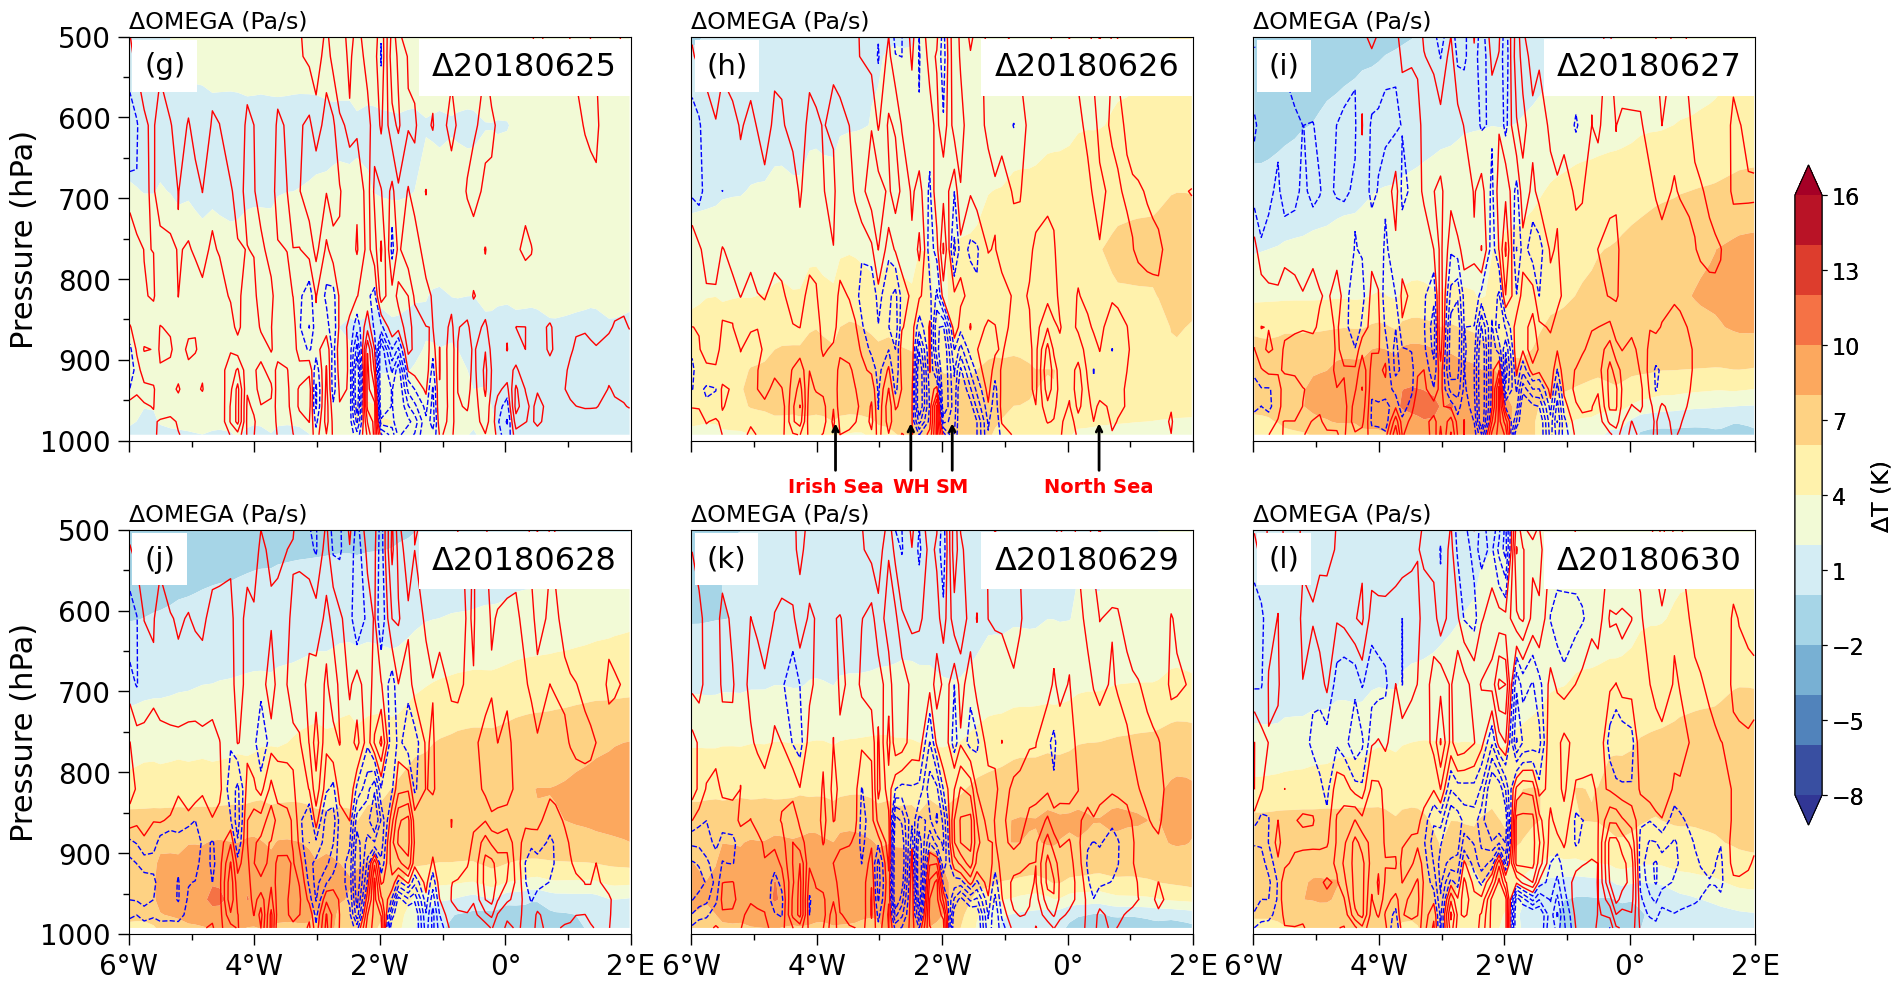

In [ ]:
base_dir = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.2_BB/atm/hist"
date_list = ['2018-06-25', '2018-06-26', '2018-06-27', '2018-06-28', '2018-06-29', '2018-06-30']
lat0, dlat = 53.40, 0.25
lon_min, lon_max = -6, 2
n = 10
base_file = f"{base_dir}/MUSICA_production3.2_BB.cam.h3.2018-06-24-00000.nc"
ds_base = xr.open_dataset(base_file)
lat = ds_base['lat'].values
lon = ds_base['lon'].values
lev = ds_base['lev'].values

idx_lat = np.where(np.abs(lat - lat0) <= dlat)[0]
lon_ = lon.copy()
lon_[lon_ > 180] -= 360
idx_lon = np.where((lon_[idx_lat] >= lon_min) & (lon_[idx_lat] <= lon_max))[0]
idx_sel = idx_lat[idx_lon]
lon_sel = lon_[idx_sel]
sorter = np.argsort(lon_sel)
lon_sel = lon_sel[sorter]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()
for i, date_str in enumerate(date_list):
    file_nc = f"{base_dir}/MUSICA_production3.2_BB.cam.h3.{date_str}-00000.nc"
    ds_1 = xr.open_dataset(file_nc)
    
    T_1 = ds_1['T'][0,:,:].values
    T_0 = ds_base['T'][0,:,:].values
    T = T_1 - T_0

    OMEGA_1 = ds_1['OMEGA'][0,:,:].values
    OMEGA_0 = ds_base['OMEGA'][0,:,:].values
    OMEGA = (OMEGA_1 - OMEGA_0) * 100

    T_sel = T[:, idx_sel][:, sorter]
    OMEGA_sel = OMEGA[:, idx_sel][:, sorter]
    lon_sel_sparse = lon_sel[::n]
    T_sel_sparse = T_sel[:, ::n]
    OMEGA_sel_sparse = OMEGA_sel[:, ::n]
    OMEGA_sel_sparse = np.clip(OMEGA_sel_sparse, -60, 40)
    Lon, Lev = np.meshgrid(lon_sel_sparse, lev)
    ax = axes[i]

    T_smooth = gaussian_filter(T_sel_sparse, sigma=0.6, mode='nearest')
    temp_levels = np.arange(-8, 17, 2)
    cf = ax.contourf(
            Lon, Lev, T_smooth, levels=temp_levels,
            cmap='RdYlBu_r', extend='both',
            antialiased=True)
        
    if i in [2, 5]:
        cax = fig.add_axes([1, 0.17, 0.015, 0.66]) 
        cbar = fig.colorbar(
            cf,
            cax=cax,
            orientation='vertical',
            shrink=0.85,   
            ticks=np.arange(-8, 18, 3),
            aspect=18,
            extend='both'
        )
        cbar.set_label('ΔT (K)', fontsize=17)
        cbar.ax.tick_params(labelsize=16)

    neg_levels = np.arange(-45, 0, 12)
    pos_levels = np.arange(0, 40, 12)
    ax.contour(Lon, Lev, OMEGA_sel_sparse, levels=neg_levels, colors='b', linestyles='dashed', linewidths=1)
    ax.contour(Lon, Lev, OMEGA_sel_sparse, levels=pos_levels, colors='r', linestyles='solid', linewidths=1)

    if i == 1:
        saddle_lon = -1.94+0.1
        ax.annotate(
            '',
            xy=(saddle_lon, 0.05), 
            xycoords=('data', 'axes fraction'),
            xytext=(saddle_lon, -0.08),
            textcoords=('data', 'axes fraction'),
            arrowprops=dict(arrowstyle='->', color='k', linewidth=2)
        )
        ax.text(
            saddle_lon, -0.09, 'SM',
            transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=14,
            color='r', weight='bold'
        )   
        
        WH_lon = -2.5
        ax.annotate(
            '',
            xy=(WH_lon, 0.05),
            xycoords=('data', 'axes fraction'),
            xytext=(WH_lon, -0.08),
            textcoords=('data', 'axes fraction'),
            arrowprops=dict(arrowstyle='->', color='k', linewidth=2)
        )
        ax.text(
            WH_lon, -0.09, 'WH',
            transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=14,
            color='r', weight='bold'
        )      
       
        irish_sea_lon = -3.6-0.1
        ax.annotate(
            '',
            xy=(irish_sea_lon, 0.05),
            xycoords=('data', 'axes fraction'),
            xytext=(irish_sea_lon, -0.08),
            textcoords=('data', 'axes fraction'),
            arrowprops=dict(arrowstyle='->', color='k', linewidth=2)
        )
        ax.text(
            irish_sea_lon, -0.09, 'Irish Sea',
            transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=14,
            color='r', weight='bold'
        )
        
        north_sea_lon = 0.5
        ax.annotate(
            '',
            xy=(north_sea_lon, 0.05),
            xycoords=('data', 'axes fraction'),
            xytext=(north_sea_lon, -0.08), 
            textcoords=('data', 'axes fraction'),
            arrowprops=dict(arrowstyle='->', color='k', linewidth=2)
        )
        ax.text(
            north_sea_lon, -0.09, 'North Sea',
            transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=14,
            color='r', weight='bold'
        )
    xticks = np.arange(np.ceil(lon_min), np.floor(lon_max)+1, 2)
    xticklabels = []
    for val in xticks:
        if val < 0:
            xticklabels.append(f'{-int(val)}°W')
        elif val > 0:
            xticklabels.append(f'{int(val)}°E')
        else:
            xticklabels.append('0°')
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=18)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))    
    ax.tick_params(axis='x', which='major', labelsize=20, pad=5, length=8, width=1 )
    ax.tick_params(axis='x', which='minor', labelsize=16*0.8, length=4, width=1 )
    
    if i in [1,2,4,5]:
        ax.set_ylabel("", fontsize=20, labelpad=25)
        ax.yaxis.set_tick_params(labelleft=False, labelright=False)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=20, pad=12, length=8, width=1, labelleft=False, labelright=False, left=False, right=False)
        ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1, labelleft=False, labelright=False, left=False, right=False)

    if i % 3 == 0:
        ax.set_ylabel('Pressure (hPa)', fontsize=22, labelpad=1)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='y', which='major', labelsize=20, pad=5, length=8, width=1 )
        ax.tick_params(axis='y', which='minor', labelsize=16*0.8, length=4, width=1 )

    ax.invert_yaxis()
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(1000, 500)
    ax.text(0.0, 1.01, 'ΔOMEGA (Pa/s)', fontsize=17, ha='left',
        va='bottom', transform=ax.transAxes)
    day = 25 + i
    date_str = f"Δ201806{day:02d}"
    ax.text(0.972, 0.962, date_str,transform=ax.transAxes, 
            # fontsize=21,
            fontsize=23,
            va='top', ha='right',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square, pad=0.4', alpha=1))

    ax.text(0.030, 0.962, f'({chr(ord("g") + i)})', transform=ax.transAxes,
            fontsize=21, va='top', ha='left',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='square,pad=0.4', alpha=1))
plt.tight_layout()
fig.subplots_adjust(wspace=0.12, hspace=0.22)


In [ ]:
print('OMEGA max:', np.nanmax(OMEGA_sel_sparse))
print('OMEGA min:', np.nanmin(OMEGA_sel_sparse))


OMEGA max: 40.0
OMEGA min: -60.0
